In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt



In [ ]:
# Load feature-engineered dataset
batting_df = pd.read_csv("dataset.csv")

# Load preprocessing pipeline
preprocessor = joblib.load("feature_pipeline.pkl")

batting_df.head()


,matchId,batsman,runs_in_match,season,venue,team1,team2,date,batting_team,opponent_team,avg_last_3,avg_last_5,avg_last_10,avg_at_venue,avg_vs_opponent,career_avg,venue_avg,opponent_avg
0,548346,A Ashish Reddy,10.0,2012,Wankhede Stadium,Mumbai Indians,Deccan Chargers,2012-04-29,Deccan Chargers,Mumbai Indians,10.000000,0.0,0.0,10.000000,13.500000,0.00,10.000000,13.500000
1,548352,A Ashish Reddy,3.0,2012,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Deccan Chargers,2012-05-04,Deccan Chargers,Chennai Super Kings,6.500000,0.0,0.0,19.500000,15.000000,10.00,19.500000,15.000000
2,548359,A Ashish Reddy,8.0,2012,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Kings XI Punjab,2012-05-08,Deccan Chargers,Kings XI Punjab,7.000000,0.0,0.0,8.454545,12.333333,6.50,8.454545,12.333333
3,548373,A Ashish Reddy,10.0,2012,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Rajasthan Royals,2012-05-18,Deccan Chargers,Rajasthan Royals,7.000000,0.0,0.0,8.454545,12.333333,7.00,8.454545,12.333333
4,548376,A Ashish Reddy,4.0,2012,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Royal Challengers Bangalore,2012-05-20,Deccan Chargers,Royal Challengers Bangalore,7.333333,0.0,0.0,8.454545,11.000000,7.75,8.454545,11.000000


In [ ]:
batting_df['season'].unique()



array(['2012', '2013', '2015', '2016', '2007/08', '2009', '2017', '2018',
       '2009/10', '2011', '2014', '2019'], dtype=object)

In [ ]:
batting_df['season'] = (
    batting_df['season']
    .astype(str)
    .str.split('/')   # split on /
    .str[0]           # take first year
    .astype(int)
)


In [ ]:
batting_df['season'].unique()
batting_df['season'].dtype


dtype('int64')

In [ ]:
batting_df['date'] = pd.to_datetime(batting_df['date'])
batting_df = batting_df.sort_values('date')

train_df = batting_df[batting_df['season'] <= 2021]
test_df = batting_df[batting_df['season'] > 2021]

train_df.shape, test_df.shape


((10712, 18), (0, 18))

In [ ]:
target = 'runs_in_match'

drop_cols = ['matchId', 'batsman', 'date', target]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]


In [ ]:
batting_df['season'] = (
    batting_df['season']
    .astype(str)
    .str.split('/')
    .str[0]
    .astype(int)
)




In [ ]:
batting_df['season'] = (
    batting_df['season']
    .astype(str)
    .str.split('/')
    .str[0]
    .astype(int)
)


In [ ]:
train_df = batting_df[batting_df['season'] <= 2016]
test_df  = batting_df[batting_df['season'] > 2016]

train_df.shape, test_df.shape


((8617, 18), (2095, 18))

In [ ]:
batting_df['season'].max()


2019

In [ ]:
train_df = batting_df[batting_df['season'] <= 2014]
test_df  = batting_df[batting_df['season'] > 2014]


In [ ]:
test_df.shape[0] > 0


True

In [ ]:
target = 'runs_in_match'

y_test = test_df[target]



In [ ]:
y_train = train_df[target]


In [ ]:
len(y_test), len(test_df)


(3841, 3841)

In [ ]:
# ===== BASELINE MODEL =====
baseline_pred = test_df['avg_last_5'].fillna(0)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5





In [ ]:
baseline_pred = test_df['avg_last_5'].fillna(0)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

baseline_mae, baseline_rmse


(16.19052330122364, 22.155092011922587)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [ ]:
# Identify categorical and numeric columns dynamically
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

categorical_cols, numeric_cols


(['venue', 'team1', 'team2', 'batting_team', 'opponent_team'],
 ['season',
  'avg_last_3',
  'avg_last_5',
  'avg_last_10',
  'avg_at_venue',
  'avg_vs_opponent',
  'career_avg',
  'venue_avg',
  'opponent_avg'])

In [ ]:
X_train = X_train.drop(columns=['team1', 'team2'])
X_test = X_test.drop(columns=['team1', 'team2'])


In [ ]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

categorical_cols, numeric_cols


(['venue', 'batting_team', 'opponent_team'],
 ['season',
  'avg_last_3',
  'avg_last_5',
  'avg_last_10',
  'avg_at_venue',
  'avg_vs_opponent',
  'career_avg',
  'venue_avg',
  'opponent_avg'])

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])


In [ ]:
# Target column
target = 'runs_in_match'

# Columns to drop
drop_cols = ['matchId', 'batsman', 'date', target]

# Recreate X and y from train_df and test_df
X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]


In [ ]:
X_train.shape, y_train.shape


((6871, 14), (6871,))

In [ ]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

categorical_cols, numeric_cols


(['venue', 'team1', 'team2', 'batting_team', 'opponent_team'],
 ['season',
  'avg_last_3',
  'avg_last_5',
  'avg_last_10',
  'avg_at_venue',
  'avg_vs_opponent',
  'career_avg',
  'venue_avg',
  'opponent_avg'])

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['venue', 'team1', 'team2',
                                                   'batting_team',
                                                   'opponent_team']),
                                                 ('num', 'passthrough',
                                                  ['season', 'avg_last_3',
                                                   'avg_last_5', 'avg_last_10',
                                                   'avg_at_venue',
                                                   'avg_vs_opponent',
                                                   'career_avg', 'venue_avg',
                                                   'opponent_avg'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = mean_squared_error(y_test, y_pred) ** 0.5

rf_mae, rf_rmse


(8.439459342185195, 12.286281478387675)

In [ ]:
import joblib
joblib.dump(pipeline, "batting_prediction_model.pkl")


['batting_prediction_model.pkl']

In [ ]:
!pip install xgboost


In [ ]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

xgb_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['venue', 'team1', 'team2',
                                                   'batting_team',
                                                   'opponent_team']),
                                                 ('num', 'passthrough',
                                                  ['season', 'avg_last_3',
                                                   'avg_last_5', 'avg_last_10',
                                                   'avg_at_venue',
                                                   'avg_vs_opponent',
                                                   'career_avg', 'venue_avg',
                                                   'opponent_avg'])])),
                ('model',
                 XGBRegressor(base_score=...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

xgb_pred = xgb_pipeline.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5

xgb_mae, xgb_rmse


(8.413472151062244, 12.231569104950811)

In [ ]:
!pip install lightgbm


In [ ]:
from lightgbm import LGBMRegressor


In [ ]:
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


In [ ]:
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgbm_model)
])

lgbm_pipeline.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000995 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 6871, number of used features: 85
[LightGBM] [Info] Start training from score 19.010333


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['venue', 'team1', 'team2',
                                                   'batting_team',
                                                   'opponent_team']),
                                                 ('num', 'passthrough',
                                                  ['season', 'avg_last_3',
                                                   'avg_last_5', 'avg_last_10',
                                                   'avg_at_venue',
                                                   'avg_vs_opponent',
                                                   'career_avg', 'venue_avg',
                                                   'opponent_avg'])])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05,
                               n_estimators=300, random_state=42,
                               subsample=0.8))])

In [ ]:
lgbm_pred = lgbm_pipeline.predict(X_test)

lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = mean_squared_error(y_test, lgbm_pred) ** 0.5

lgbm_mae, lgbm_rmse


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


(8.439585700092948, 12.284620414334436)

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline (Avg Last 5)",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae,
        lgbm_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse,
        lgbm_rmse
    ]
})

comparison


,Model,MAE,RMSE
0,Baseline (Avg Last 5),16.190523,22.155092
1,Random Forest,8.439459,12.286281
2,XGBoost,8.413472,12.231569
3,LightGBM,8.439586,12.284620


In [ ]:
import joblib
joblib.dump(xgb_pipeline, "best_batting_model.pkl")


['best_batting_model.pkl']

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline


In [ ]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)


In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])


In [ ]:
param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [4, 6],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}


In [ ]:
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)


In [ ]:
grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 32 candidates, totalling 96 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['venue',
                                                                          'team1',
                                                                          'team2',
                                                                          'batting_team',
                                                                          'opponent_team']),
                                                                        ('num',
                                                                         'passthrough',
                                                                         ['season',
                                                                          'avg_last_3',
                                                                          'avg_last_5',
                                                                          'avg_last_10',
                                                                          'avg_at_venue',
                                                                          'avg_vs_opponent',
                                                                          'career_avg',
                                                                          'venue_avg',
                                                                          'opponent_avg'])])),
                                       ('mod...
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=-1,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [4, 6],
                         'model__n_estimators': [200, 300],
                         'model__subsample': [0.8, 1.0]},
             scoring='neg_mean_absolute_error', verbose=2)

In [ ]:
grid_search.best_params_


{'model__colsample_bytree': 1.0,
 'model__learning_rate': 0.05,
 'model__max_depth': 6,
 'model__n_estimators': 200,
 'model__subsample': 0.8}

In [ ]:
best_mae = -grid_search.best_score_
best_mae


np.float64(7.808662351676515)

In [ ]:
best_model = grid_search.best_estimator_

tuned_pred = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = mean_squared_error(y_test, tuned_pred) ** 0.5

tuned_mae, tuned_rmse


(8.302899400113198, 12.10511449199293)

In [ ]:
import joblib
joblib.dump(best_model, "xgb_tuned_model.pkl")


['xgb_tuned_model.pkl']

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "XGBoost (Default)",
        "XGBoost (Tuned)"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae,
        tuned_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse,
        tuned_rmse
    ]
})

comparison


,Model,MAE,RMSE
0,Baseline,16.190523,22.155092
1,Random Forest,8.439459,12.286281
2,XGBoost (Default),8.413472,12.231569
3,XGBoost (Tuned),8.302899,12.105114


In [ ]:
from sklearn.metrics import r2_score


In [ ]:
r2 = r2_score(y_test, tuned_pred)   # use tuned_pred
r2


0.6892187265083413

In [ ]:
print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("R2  :", r2)


MAE : 8.302899400113198
RMSE: 12.10511449199293
R2  : 0.6892187265083413


In [ ]:
!pip install shap


In [ ]:
import shap


In [ ]:
X_test_transformed = preprocessor.transform(X_test)


In [ ]:
xgb_model = best_model.named_steps['model']


In [ ]:
explainer = shap.TreeExplainer(xgb_model)


In [ ]:
shap_values = explainer.shap_values(X_test_transformed[:500])


In [ ]:
feature_names = (
    best_model.named_steps['preprocessor']
    .get_feature_names_out()
)


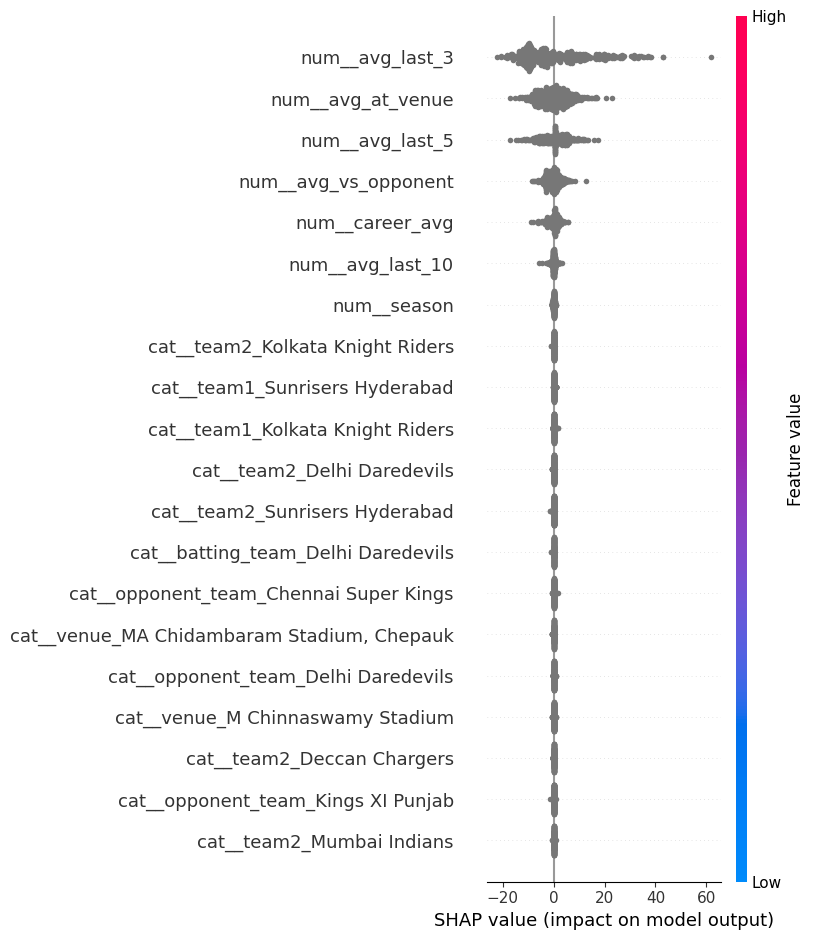

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_transformed[:500],
    feature_names=feature_names
)


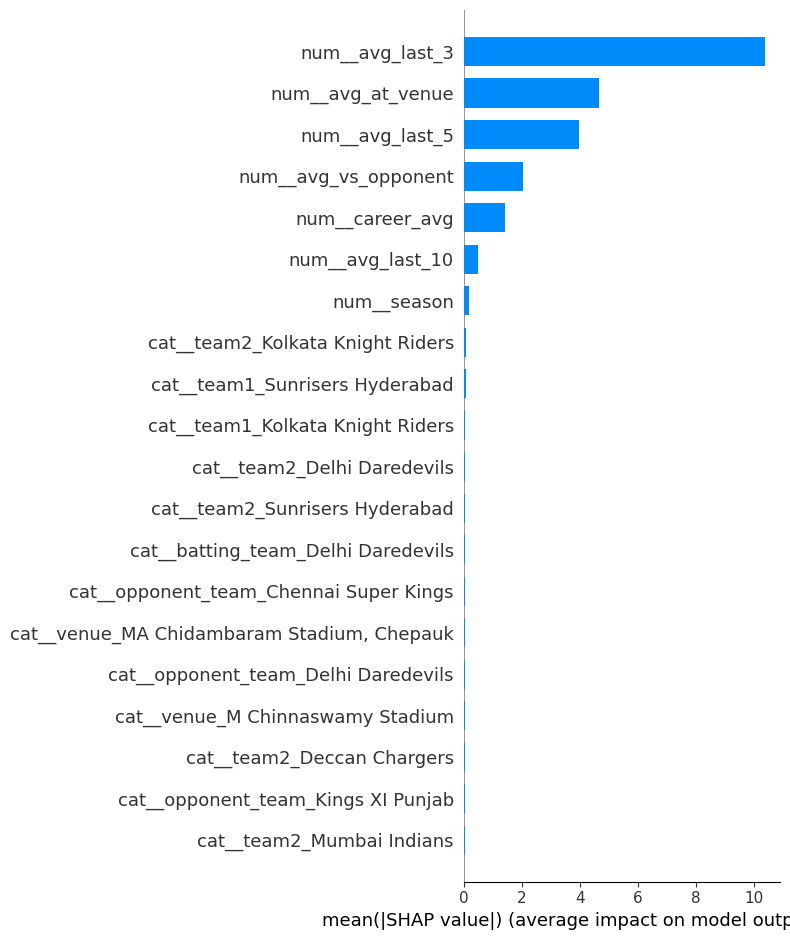

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_transformed[:500],
    feature_names=feature_names,
    plot_type="bar"
)


In [139]:
import joblib

joblib.dump(best_model, "xgb_model.joblib")


['xgb_model.joblib']